# TRABAJO FINAL :)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
from scipy.stats import expon
from matplotlib.ticker import AutoMinorLocator

# Implementacion de generadores

In [ ]:
#Generador 1: LCG
def LCG(x, a=16807, c=0, m=2**31 - 1):
    x = (a * x + c) % m
    return  x / m, x

In [ ]:
#  Generador 2: XORShift
def XORShift(x):
    x ^= (x << 13) & 0xFFFFFFFF
    x ^= (x >> 17)
    x ^= (x << 5) & 0xFFFFFFFF
    return (x & 0xFFFFFFFF) / 0xFFFFFFFF, x #estandarizo

In [ ]:
#  Generador 3: Mersenne Twister
# Mersenne Twister

def MT():
    return np.random.rand()# usa MT19937 por defecto

# Aplicación de los generadores

In [ ]:
# TASA DE LLEGADAS
def lambda_t(t):
    return 30 + 30 * math.sin(2 * math.pi * t / 24)  # t en horas

def generar_arribos_poisson(rand_func,estado_inicial, T_max=48,lambda_max=60):

    """Esta función simula los tiempos de llegada de clientes a un
    sistema durante un tiempo total de T_max horas."""

    t = 0
    arribos = []
    estado = estado_inicial

    while t < T_max:
        u , estado = rand_func(estado)
        t += -math.log(u) / lambda_max  # paso del proceso de Poisson homogéneo

        u2 , estado = rand_func(estado)
        if u2 <= lambda_t(t) / lambda_max:
            arribos.append(t)

    return arribos , estado

In [ ]:
#Tiempos de servicio exponenciales (cuanto tarda en atenderlo)
def generar_tiempo_servicio(rand_func,estado, mu=40):
    u, estado = rand_func(estado)
    return -math.log(u) / mu , estado


# Simulación de sistema de cola

In [ ]:
#SIMULACION DE SISTEMA DE COLAS

def simular_cola(rand_func, estado_inicial, T_max=48):
    # Generar los tiempos de llegada
    arribos , estado = generar_arribos_poisson(rand_func, estado_inicial, T_max)

    servidor_libre_en = 0
    clientes = []

    for llegada in arribos:
       # Determinar cuándo comienza el servicio
        if llegada >= servidor_libre_en:
            # servidor está libre
            inicio = llegada
        else:
            # cliente espera
            inicio = servidor_libre_en

        # Generar tiempo de servicio
        servicio , estado= generar_tiempo_servicio(rand_func, estado)
        salida = inicio + servicio
        servidor_libre_en = salida

        clientes.append({
            'llegada': llegada, # Tiempo en que el cliente llega al sistema
            'inicio': inicio,   # Tiempo en que comienza a ser atendido
            'salida': salida,   # Tiempo en que finaliza el servicio
            'espera': inicio - llegada, # Tiempo que pasó en la cola (antes de ser atendido)
            'tiempo_total': salida - llegada  # Tiempo total en el sistema
        })

    return clientes


In [ ]:
#Ejecutar simulación con cada generador y guardar resultados

# LCG
estado_lcg = 123
datos_lcg = simular_cola(LCG, estado_lcg)

# XORShift
estado_xor = 987654321
datos_xorshift = simular_cola(XORShift, estado_xor)

# Mersenne Twister (no necesita estado)
np.random.seed(42)  # Semilla reproducible
def MT_wrapper(_):  # Ignora estado
    return MT(), None

datos_mt = simular_cola(MT_wrapper, None)

#longitud
#len(datos_lcg), len(datos_xorshift), len(datos_mt)

In [ ]:
#Convertir resultados a DataFrame
def resultados_a_dataframe(clientes, nombre_generador):
    df = pd.DataFrame(clientes)
    df['generador'] = nombre_generador
    return df

df_lcg = resultados_a_dataframe(datos_lcg, "LCG")
df_xor = resultados_a_dataframe(datos_xorshift, "XORShift")
df_mt = resultados_a_dataframe(datos_mt, "M-T")

df_todos = pd.concat([df_lcg, df_xor, df_mt])
#print(df_todos)

# Estadisticas y graficas

**Tasa de utilización del servidor por hora**

El gráfico muestra cómo varía el uso del servidor a lo largo de las 48 horas simuladas. Se observan picos y valles que reflejan la naturaleza periódica de la tasa de llegadas $λ(t)$, con mayor ocupación en las horas de alta demanda.

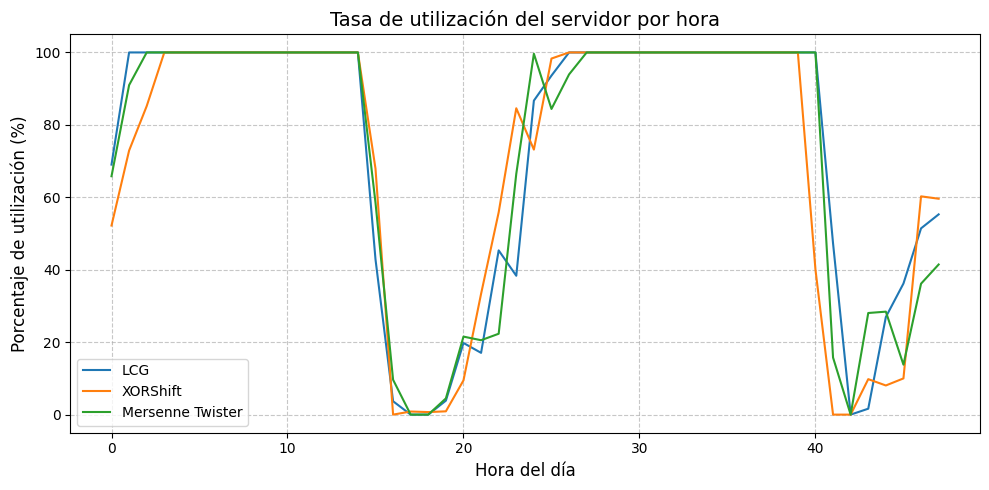

In [ ]:
#Tasa de utilización del servidor por hora
def utilizacion_por_hora(clientes, T_max=48, intervalo=1):
    horas = np.arange(0, T_max, intervalo)
    utilizacion = []

    for h in horas:
        tiempo_ocupado = 0
        inicio_ventana = h
        fin_ventana = h + intervalo

        for c in clientes:
            inicio_serv = c['inicio']
            fin_serv = c['salida']

            if fin_serv <= inicio_ventana or inicio_serv >= fin_ventana:
                continue
            else:
                interseccion = min(fin_serv, fin_ventana) - max(inicio_serv, inicio_ventana)
                tiempo_ocupado += interseccion

        utilizacion.append(tiempo_ocupado / intervalo)

    return horas, utilizacion
plt.figure(figsize=(10, 5))

for datos, nombre in [(datos_lcg, "LCG"), (datos_xorshift, "XORShift"), (datos_mt, "Mersenne Twister")]:
    horas, uso = utilizacion_por_hora(datos)
    plt.plot(horas, np.array(uso)*100, label=nombre)  # convertir a porcentaje

plt.title("Tasa de utilización del servidor por hora")
plt.xlabel("Hora del día")
plt.ylabel("Porcentaje de utilización (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Tiempo promedio que un cliente pasa en el sistema**

Tiempo promedio en el sistema:
generador
LCG         1.772165
M-T         1.439030
XORShift    1.380872
Name: tiempo_total, dtype: float64


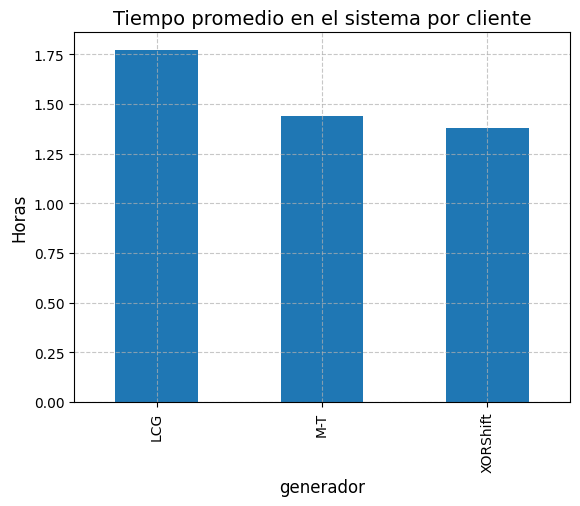

In [ ]:
# Tiempo promedio en el sistema por cliente
promedios = df_todos.groupby('generador')['tiempo_total'].mean()
print("Tiempo promedio en el sistema:")
print(promedios)

promedios.plot(kind='bar', title='Tiempo promedio en el sistema por cliente')
plt.ylabel('Horas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


**Distribución de los tiempos de espera**

El gráfico muestra cuántos clientes esperaron cierto tiempo antes de ser atendidos. La mayoría tuvo esperas muy cortas, cercanas a cero, pero también hubo algunos casos con esperas largas, especialmente cuando el sistema se congestionó

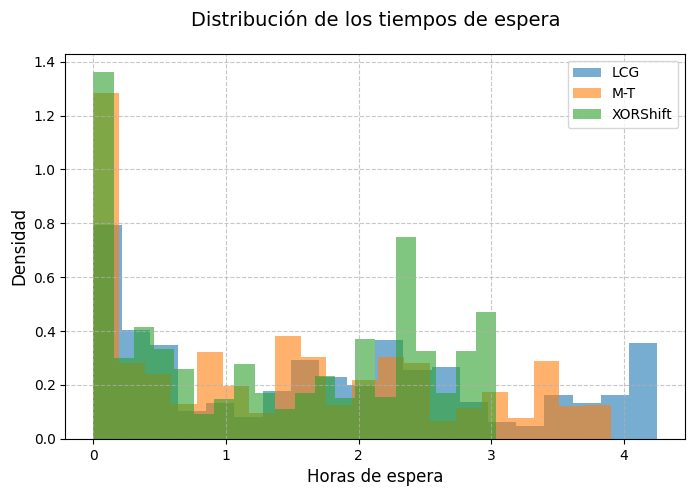

In [ ]:
#Distribución de los tiempos de espera
plt.figure(figsize=(8, 5))
for name, df in df_todos.groupby('generador'):
    plt.hist(df['espera'], bins=20, alpha=0.6, label=name, density=True)
plt.title('Distribución de los tiempos de espera', pad=20)
plt.xlabel('Horas de espera')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**El porcentaje de tiempo que el servidor está ocupado.**

Representa la utilización del servidor, es decir, cuánto tiempo estuvo trabajando. Un valor cercano a 100% indicaría un servidor constantemente ocupado.

In [ ]:
#Porcentaje de tiempo ocupado
def porcentaje_ocupado(clientes):
    tiempo_ocupado = sum([c['salida'] - c['inicio'] for c in clientes])
    return 100 * tiempo_ocupado / 48  # 48 horas

print("Porcentaje de tiempo ocupado:")
print({
    "LCG": porcentaje_ocupado(datos_lcg),
    "XORShift": porcentaje_ocupado(datos_xorshift),
    "Mersenne Twister": porcentaje_ocupado(datos_mt)
})


Porcentaje de tiempo ocupado:
{'LCG': 74.15517851304212, 'XORShift': 71.40404814999818, 'Mersenne Twister': 73.12428729012176}


**Evolución de la longitud de la cola**

***Interpretación del gráfico:***

*   Los picos altos indican momentos con muchos clientes esperando.   
*   Las áreas planas en cero muestran períodos donde el servidor está desocupado.


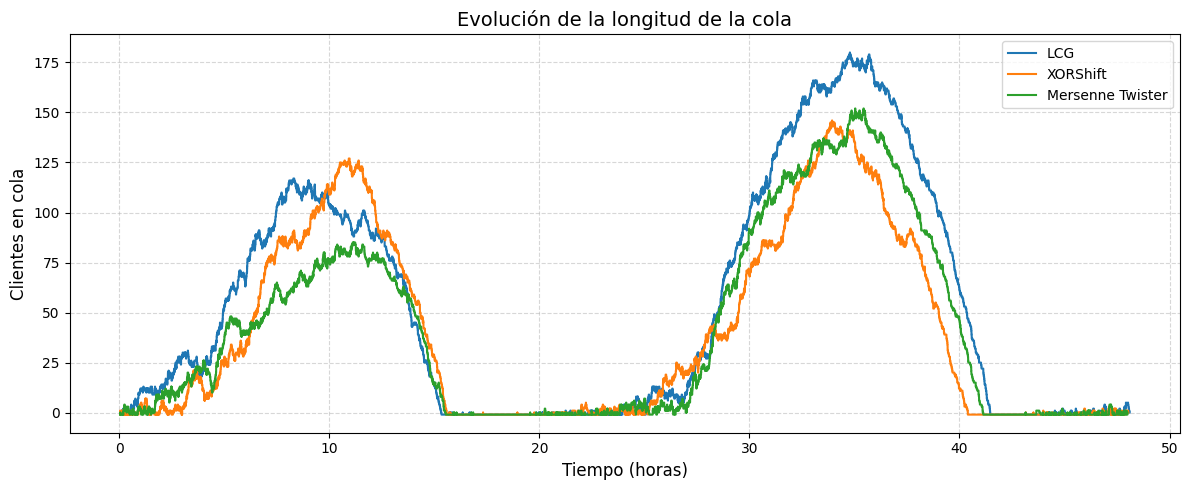

In [ ]:
#Evolución de la longitud de la cola
def cola_vs_tiempo(clientes):
    eventos = []
    for c in clientes:
        eventos.append((c['llegada'], +1)) # cuando llega un cliente, la cola crece
        eventos.append((c['inicio'], -1)) # cuando comienza a ser atendido, la cola baja

    eventos.sort() # ordenamos todos los eventos por tiempo
    tiempos, colas = [], []
    cola_actual = 0
    for t, delta in eventos:
        cola_actual += delta
        tiempos.append(t)
        colas.append(cola_actual)

    return tiempos, colas

plt.figure(figsize=(12, 5))
colors = {'LCG': '#1f77b4', 'XORShift': '#ff7f0e', 'Mersenne Twister': '#2ca02c'}
for datos, nombre in [(datos_lcg, "LCG"), (datos_xorshift, "XORShift"), (datos_mt, "Mersenne Twister")]:
    t, c = cola_vs_tiempo(datos)
    plt.step(t, c, label=nombre, color=colors[nombre], linewidth=1.5)
plt.title('Evolución de la longitud de la cola')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Clientes en cola')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Distribución del tiempo entre arribos y de servicios simulados**





*  ***Tiempos entre Arribos (Llegadas de Clientes):***

Los tiempos entre arribos simulados muestran una distribución exponencial decreciente, consistente con un proceso de Poisson no homogéneo. Los tres generadores producen resultados similares, validando el modelo.
*   ***Tiempos de Servicio***:

Los tiempos de servicio simulados siguen una distribución exponencial con media cercana al valor teórico.

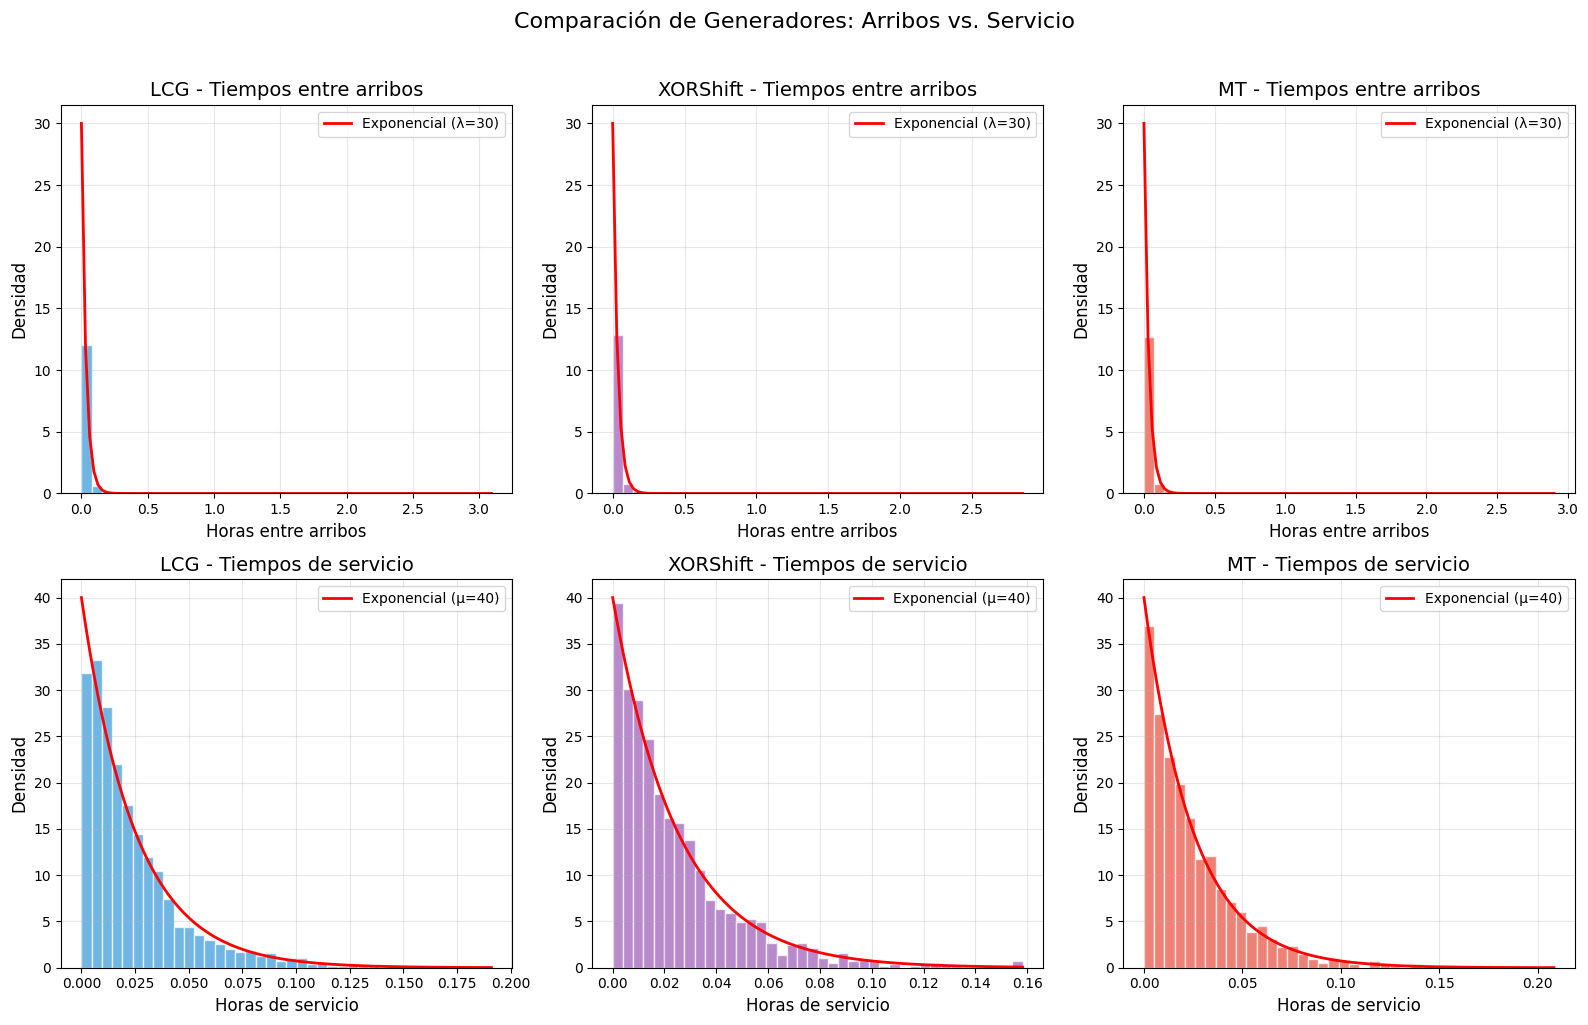

In [ ]:
#para grafica y poder comparar
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import expon

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plt.suptitle('Comparación de Generadores: Arribos vs. Servicio', y=1.02, fontsize=16)

# Colores por generador
colors = {'LCG': '#3498db', 'XORShift': '#9b59b6', 'MT': '#e74c3c'}

# Tiempos entre arribos
for i, (datos, nombre) in enumerate([(datos_lcg, "LCG"), (datos_xorshift, "XORShift"), (datos_mt, "MT")]):
    # Calcular tiempos entre arribos (diferencias entre llegadas consecutivas)
    tiempos_arribos = np.diff([c['llegada'] for c in datos])

    # Histograma + Curva teórica (usando λ promedio = 30)
    ax = axes[0, i]
    ax.hist(tiempos_arribos, bins=40, density=True, alpha=0.7, color=colors[nombre], edgecolor='white')
    x = np.linspace(0, np.max(tiempos_arribos), 100)
    ax.plot(x, expon.pdf(x, scale=1/30), 'r-', linewidth=2, label='Exponencial (λ=30)')
    ax.set_title(f'{nombre} - Tiempos entre arribos', fontsize=14)
    ax.set_xlabel('Horas entre arribos', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.legend()

#  Tiempos de servicio
for i, (datos, nombre) in enumerate([(datos_lcg, "LCG"), (datos_xorshift, "XORShift"), (datos_mt, "MT")]):
    tiempos_servicio = [c['salida'] - c['inicio'] for c in datos]

    ax = axes[1, i]
    ax.hist(tiempos_servicio, bins=40, density=True, alpha=0.7, color=colors[nombre], edgecolor='white')
    x = np.linspace(0, np.max(tiempos_servicio), 100)
    ax.plot(x, expon.pdf(x, scale=1/40), 'r-', linewidth=2, label='Exponencial (μ=40)')
    ax.set_title(f'{nombre} - Tiempos de servicio', fontsize=14)
    ax.set_xlabel('Horas de servicio', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

# Validación estadística


Realizamos una validación estadística para verificar si los tiempos de servicio generados en tu simulación siguen una distribución exponencial con parámetro $μ=40$. Usamos Test de Kolmogorov-Smirnov (K-S)


*   Hipótesis nula $(H₀)$: *Los tiempos de servicio siguen una distribución exponencial con $μ=40$.*
*   Hipótesis alternativa $(H₁)$:*Los tiempos de servicio no siguen una exponencial con $μ=40$.*

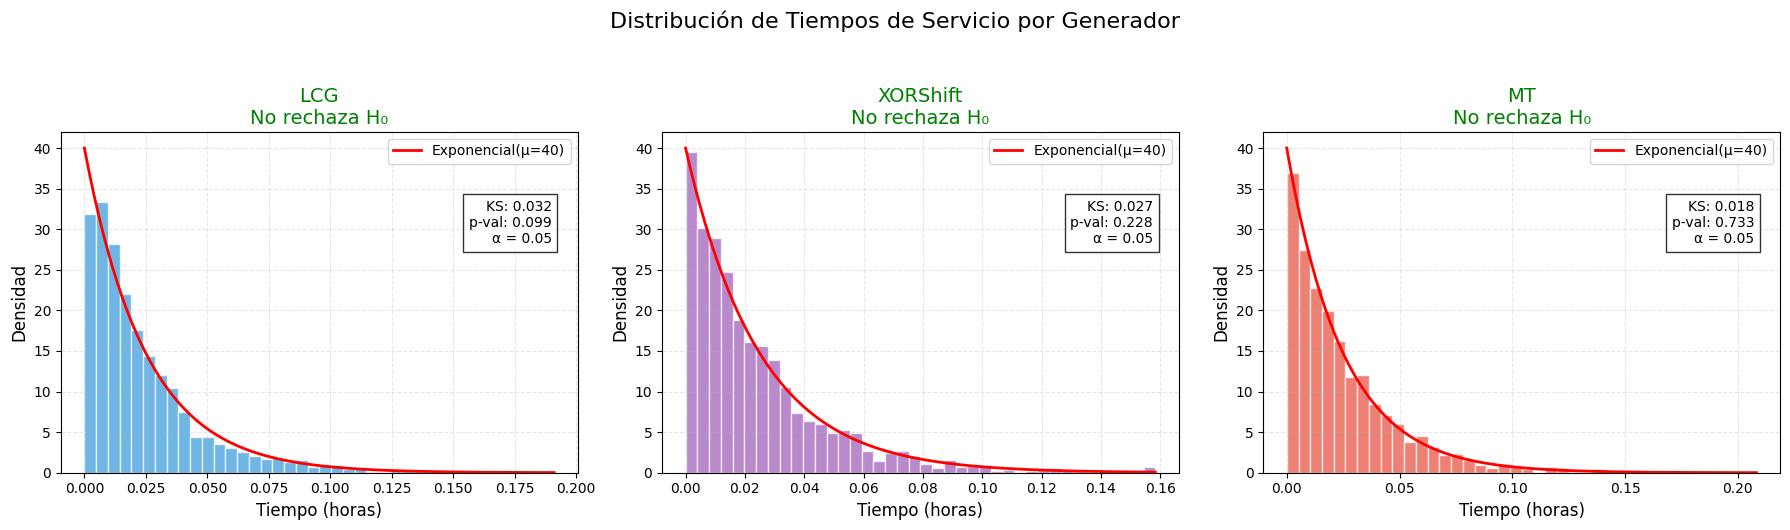

In [ ]:
from scipy.stats import kstest, expon

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Tiempos de Servicio por Generador', y=1.05, fontsize=16)

# Paleta de colores
colors = {'LCG': '#3498db', 'XORShift': '#9b59b6', 'MT': '#e74c3c'}

# Función para test exponencial con decisión
def test_exponencial(datos, mu=40, alpha=0.05):
    scale = 1/mu
    ks_stat, p_value = kstest(datos, 'expon', args=(0, scale))
    decision = "Rechaza H₀" if p_value < alpha else "No rechaza H₀"
    return ks_stat, p_value, decision

# Generar gráficos
for i, (datos, nombre) in enumerate([(datos_lcg, "LCG"), (datos_xorshift, "XORShift"), (datos_mt, "MT")]):
    tiempos = [c['salida'] - c['inicio'] for c in datos]

    # Histograma
    n, bins, patches = axes[i].hist(tiempos, bins=40, density=True, alpha=0.7,
                                   color=colors[nombre], edgecolor='white')

    # Curva teórica
    x = np.linspace(0, np.max(tiempos), 100)
    axes[i].plot(x, expon.pdf(x, scale=1/40), 'r-', linewidth=2, label='Exponencial(μ=40)')

    # Test KS y decisión
    ks_stat, p_value, decision = test_exponencial(tiempos)
    color_decision = 'red' if "Rechaza" in decision else 'green'

    # Configuración del subplot
    axes[i].set_title(f'{nombre}\n{decision}', fontsize=14, color=color_decision)
    axes[i].set_xlabel('Tiempo (horas)', fontsize=12)
    axes[i].set_ylabel('Densidad', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].legend()

    # Anotación estadística
    stats_text = f'KS: {ks_stat:.3f}\np-val: {p_value:.3f}\nα = 0.05'
    axes[i].text(0.95, 0.80, stats_text, transform=axes[i].transAxes,
                ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()